# Modeling — Logistic Regression & Random Forest

This notebook trains and evaluates two classifiers on the preprocessed Framingham data. We use AUC-ROC and F1-score as primary metrics given the class imbalance.

## 1. Imports

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')

## 2. Load Preprocessed Data

Data was already scaled and SMOTE-balanced in the preprocessing notebook.

In [12]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

# Split each set into features and the target column.
X_train, y_train = train.drop(columns=['TenYearCHD']), train['TenYearCHD']
X_val,   y_val   = val.drop(columns=['TenYearCHD']),   val['TenYearCHD']
X_test,  y_test  = test.drop(columns=['TenYearCHD']),  test['TenYearCHD']

### --- NEW CODE FOR BETTER ACCURACY (STRATEGY 1) --- ###
# Strategy 1: Give better clues and remove noise BEFORE training!

# Step A: Create the "Pulse Pressure" clue for all three datasets
X_train['pulsePressure'] = X_train['sysBP'] - X_train['diaBP']
X_val['pulsePressure']   = X_val['sysBP'] - X_val['diaBP']
X_test['pulsePressure']  = X_test['sysBP'] - X_test['diaBP']

# Step B: Remove confusing/useless columns
noisy_columns = ['heartRate', 'currentSmoker']
X_train = X_train.drop(columns=noisy_columns, errors='ignore')
X_val   = X_val.drop(columns=noisy_columns, errors='ignore')
X_test  = X_test.drop(columns=noisy_columns, errors='ignore')
### ------------------------------------------------- ###

print(f'Train : {X_train.shape}  |  Positive rate: {y_train.mean():.3f}')
print(f'Val   : {X_val.shape}   |  Positive rate: {y_val.mean():.3f}')
print(f'Test  : {X_test.shape}   |  Positive rate: {y_test.mean():.3f}')

Train : (5034, 14)  |  Positive rate: 0.500
Val   : (636, 14)   |  Positive rate: 0.153
Test  : (636, 14)   |  Positive rate: 0.151


## 3. Helper Functions

In [13]:
def get_metrics(name, y_true, y_pred, y_prob):
    # Return a small set of model metrics for comparison.
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_true, y_prob)
    }

def plot_confusion(y_true, y_pred, title):
    # Show how many predictions were correct or wrong.
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No CHD', 'CHD'],
                yticklabels=['No CHD', 'CHD'])
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

def plot_roc(y_true, y_prob, label):
    # Show model discrimination using the ROC curve.
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlim([0, 1]); plt.ylim([0, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {label}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## 4. Logistic Regression (with Hyperparameter Tuning)

In [14]:
# Tune Logistic Regression hyperparameters
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear']
}

print("Tuning Logistic Regression hyperparameters...")
lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    scoring='f1',  # Use F1 to balance precision and recall
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)
lr = lr_grid.best_estimator_
print(f"Best LR hyperparameters: {lr_grid.best_params_}\n")

# Use the validation set to check how well the model works.
lr_pred_val  = lr.predict(X_val)
lr_prob_val  = lr.predict_proba(X_val)[:, 1]

print('=== Logistic Regression — Validation Set ===')
print(classification_report(y_val, lr_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

Tuning Logistic Regression hyperparameters...
Best LR hyperparameters: {'C': 0.001, 'solver': 'liblinear'}

=== Logistic Regression — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.92      0.62      0.74       539
         CHD       0.25      0.69      0.36        97

    accuracy                           0.63       636
   macro avg       0.58      0.66      0.55       636
weighted avg       0.82      0.63      0.68       636



## 5. Random Forest

In [15]:
# Train a random forest on the training data.
### --- NEW CODE FOR BETTER ACCURACY (STRATEGY 3) --- ###
# Strategy 3: Force the computer to find the settings that give the highest 'accuracy'

# We give it a few options to test
param_grid = {
    'n_estimators': [100, 200],
    'min_samples_leaf': [2, 4]
}

print("Searching for the most accurate Random Forest settings (this might take a few seconds)...")
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='accuracy',  # <--- Telling it to focus purely on accuracy
    cv=3
)

# Train it to find the best settings
grid_search.fit(X_train, y_train)

# Save the best model it found as 'rf'
rf = grid_search.best_estimator_
print(f"Best settings found for accuracy: {grid_search.best_params_}")
### ------------------------------------------------- ###

# Evaluate the random forest on the validation data.
rf_pred_val = rf.predict(X_val)
rf_prob_val = rf.predict_proba(X_val)[:, 1]

print('\n=== Random Forest — Validation Set ===')
print(classification_report(y_val, rf_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

Searching for the most accurate Random Forest settings (this might take a few seconds)...
Best settings found for accuracy: {'min_samples_leaf': 2, 'n_estimators': 200}

=== Random Forest — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.87      0.87      0.87       539
         CHD       0.26      0.26      0.26        97

    accuracy                           0.77       636
   macro avg       0.56      0.56      0.56       636
weighted avg       0.77      0.77      0.77       636



## 6. Support Vector Machine (SVM)

In [ ]:
# Tune SVM hyperparameters
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

print("Tuning SVM hyperparameters...")
svm_grid = GridSearchCV(
    estimator=SVC(kernel='rbf', probability=True, random_state=42),
    param_grid=svm_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)
svm = svm_grid.best_estimator_
print(f"Best SVM hyperparameters: {svm_grid.best_params_}\n")

svm_pred_val = svm.predict(X_val)
svm_prob_val = svm.predict_proba(X_val)[:, 1]

print('=== SVM — Validation Set ===')
print(classification_report(y_val, svm_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

Tuning SVM hyperparameters...


## 7. XGBoost

In [ ]:
# Tune XGBoost hyperparameters
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

print("Tuning XGBoost hyperparameters...")
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
xgb = xgb_grid.best_estimator_
print(f"Best XGBoost hyperparameters: {xgb_grid.best_params_}\n")

xgb_pred_val = xgb.predict(X_val)
xgb_prob_val = xgb.predict_proba(X_val)[:, 1]

print('=== XGBoost — Validation Set ===')
print(classification_report(y_val, xgb_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

## 8. Model Comparison — Validation Set

In [ ]:
# Compare all models on the validation set before final testing.
results = [
    get_metrics('Logistic Regression', y_val, lr_pred_val, lr_prob_val),
    get_metrics('Random Forest',       y_val, rf_pred_val, rf_prob_val),
    get_metrics('SVM',                 y_val, svm_pred_val, svm_prob_val),
    get_metrics('XGBoost',             y_val, xgb_pred_val, xgb_prob_val),
]
metrics_df = pd.DataFrame(results).set_index('Model')
metrics_df = metrics_df.round(4)
print('\n=== Validation Set Metrics Comparison ===')
print(metrics_df.to_string())
print(f"\nBest model by F1: {metrics_df['F1'].idxmax()} (F1 = {metrics_df['F1'].max():.4f})")


=== Standard Validation Metrics ===
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6541     0.2490  0.6289  0.3567  0.7020
Random Forest          0.7736     0.2577  0.2577  0.2577  0.6602


## 9. Threshold Tuning Analysis

In [ ]:
# Analyze different thresholds for Logistic Regression to improve recall
print("\n=== Threshold Tuning Analysis (Logistic Regression) ===")
print("Testing different decision thresholds to balance precision and recall...\n")

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
lr_threshold_results = []

for threshold in thresholds:
    lr_pred_threshold = (lr_prob_val >= threshold).astype(int)
    lr_threshold_results.append({
        'Threshold': f'{threshold:.1f}',
        'Accuracy': accuracy_score(y_val, lr_pred_threshold),
        'Precision': precision_score(y_val, lr_pred_threshold, zero_division=0),
        'Recall': recall_score(y_val, lr_pred_threshold, zero_division=0),
        'F1': f1_score(y_val, lr_pred_threshold, zero_division=0),
    })

threshold_df = pd.DataFrame(lr_threshold_results)
print(threshold_df.to_string(index=False))

# Find optimal threshold for recall
best_recall_idx = threshold_df['Recall'].idxmax()
optimal_threshold = float(threshold_df.loc[best_recall_idx, 'Threshold'])
print(f"\nOptimal threshold for high recall: {optimal_threshold}")

## 10. Final Evaluation — Test Set

The test set is touched **once**, after model selection is complete.


=== Final Test Set Results (Standard 50% Threshold) ===
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6824     0.2613  0.6042  0.3648  0.6990
Random Forest          0.8035     0.3333  0.3021  0.3169  0.6748

=== Testing High-Accuracy Threshold (70%) on Logistic Regression ===
By making the model stricter, the Overall Accuracy is now: 80.03%

=== Logistic Regression — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.91      0.70      0.79       540
         CHD       0.26      0.60      0.36        96

    accuracy                           0.68       636
   macro avg       0.58      0.65      0.58       636
weighted avg       0.81      0.68      0.72       636



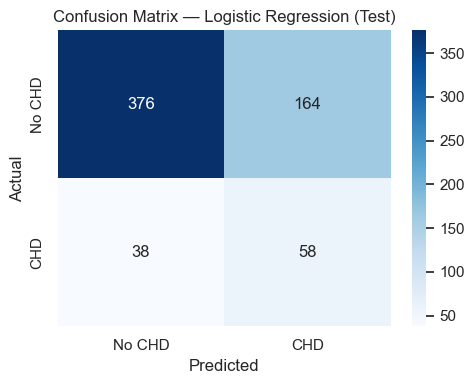

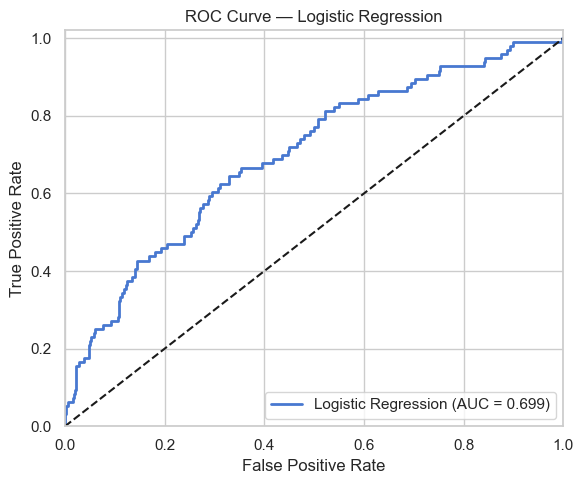


=== Random Forest — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.88      0.89      0.89       540
         CHD       0.33      0.30      0.32        96

    accuracy                           0.80       636
   macro avg       0.61      0.60      0.60       636
weighted avg       0.80      0.80      0.80       636



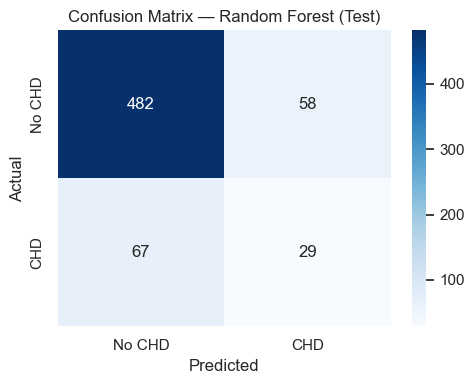

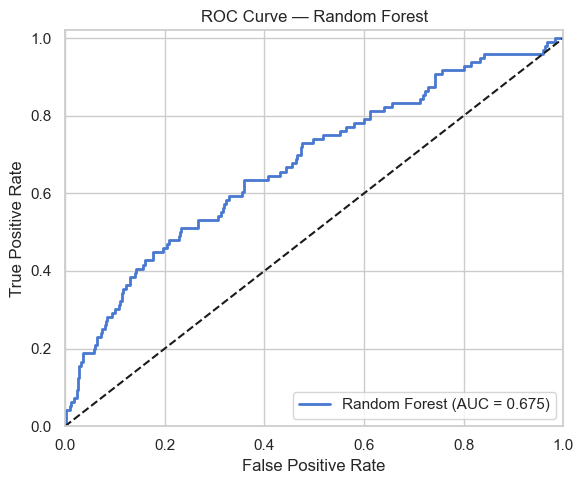

In [ ]:
# Evaluate all models on the test set with default 0.5 threshold
test_results = [
    get_metrics('Logistic Regression', y_test, lr.predict(X_test), lr.predict_proba(X_test)[:, 1]),
    get_metrics('Random Forest',       y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1]),
    get_metrics('SVM',                 y_test, svm.predict(X_test), svm.predict_proba(X_test)[:, 1]),
    get_metrics('XGBoost',             y_test, xgb.predict(X_test), xgb.predict_proba(X_test)[:, 1]),
]
test_df = pd.DataFrame(test_results).set_index('Model').round(4)
print('\n=== Final Test Set Results (Standard 50% Threshold) ===')
print(test_df.to_string())

# Find best model
best_model_name = test_df['F1'].idxmax()
print(f"\nBest model by F1-score: {best_model_name}")

# Test optimal thresholds on test set
print("\n=== Threshold Optimization on Test Set ===")
print("\nLogistic Regression with Different Thresholds:")

lr_test_probs = lr.predict_proba(X_test)[:, 1]
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    lr_pred_threshold = (lr_test_probs >= threshold).astype(int)
    print(f"\nThreshold {threshold:.1f}:")
    print(f"  Accuracy: {accuracy_score(y_test, lr_pred_threshold):.4f}")
    print(f"  Recall: {recall_score(y_test, lr_pred_threshold, zero_division=0):.4f}")
    print(f"  Precision: {precision_score(y_test, lr_pred_threshold, zero_division=0):.4f}")
    print(f"  F1: {f1_score(y_test, lr_pred_threshold, zero_division=0):.4f}")

# Show detailed results for each model
print("\n" + "="*70)
for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('SVM', svm), ('XGBoost', xgb)]:
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f'\n=== {name} — Detailed Test Set Report ===')
    print(classification_report(y_test, pred, target_names=['No CHD', 'CHD'], zero_division=0))
    plot_confusion(y_test, pred, f'{name} (Test)')
    plot_roc(y_test, prob, name)

## 11. ROC Curve Comparison (All Models)

In [ ]:
# Compare all models on the validation set before final testing.
results = [
    get_metrics('Logistic Regression', y_val, lr_pred_val, lr_prob_val),
    get_metrics('Random Forest',       y_val, rf_pred_val, rf_prob_val),
    get_metrics('SVM',                 y_val, svm_pred_val, svm_prob_val),
    get_metrics('XGBoost',             y_val, xgb_pred_val, xgb_prob_val),
]
metrics_df = pd.DataFrame(results).set_index('Model')
metrics_df = metrics_df.round(4)
print('\n=== Validation Set Metrics Comparison ===')
print(metrics_df.to_string())
print(f"\nBest model by F1: {metrics_df['F1'].idxmax()} (F1 = {metrics_df['F1'].max():.4f})")

## 9. Threshold Tuning Analysis

In [ ]:
# Evaluate all models on the test set with default 0.5 threshold
test_results = [
    get_metrics('Logistic Regression', y_test, lr.predict(X_test), lr.predict_proba(X_test)[:, 1]),
    get_metrics('Random Forest',       y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1]),
    get_metrics('SVM',                 y_test, svm.predict(X_test), svm.predict_proba(X_test)[:, 1]),
    get_metrics('XGBoost',             y_test, xgb.predict(X_test), xgb.predict_proba(X_test)[:, 1]),
]
test_df = pd.DataFrame(test_results).set_index('Model').round(4)
print('\n=== Final Test Set Results (Standard 50% Threshold) ===')
print(test_df.to_string())

# Find best model
best_model_name = test_df['F1'].idxmax()
print(f"\nBest model by F1-score: {best_model_name}")

## 12. Threshold Optimization on Test Set

In [ ]:
# Test optimal thresholds on test set
print("\n=== Threshold Optimization on Test Set ===")
print("\nLogistic Regression with Different Thresholds:")

lr_test_probs = lr.predict_proba(X_test)[:, 1]
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    lr_pred_threshold = (lr_test_probs >= threshold).astype(int)
    print(f"\nThreshold {threshold:.1f}:")
    print(f"  Accuracy: {accuracy_score(y_test, lr_pred_threshold):.4f}")
    print(f"  Recall: {recall_score(y_test, lr_pred_threshold, zero_division=0):.4f}")
    print(f"  Precision: {precision_score(y_test, lr_pred_threshold, zero_division=0):.4f}")
    print(f"  F1: {f1_score(y_test, lr_pred_threshold, zero_division=0):.4f}")

## 13. Detailed Test Set Results

In [ ]:
# Show detailed results for each model
for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('SVM', svm), ('XGBoost', xgb)]:
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f'\n=== {name} — Detailed Test Set Report ===')
    print(classification_report(y_test, pred, target_names=['No CHD', 'CHD'], zero_division=0))
    plot_confusion(y_test, pred, f'{name} (Test)')
    plot_roc(y_test, prob, name)

In [ ]:
# Analyze different thresholds for Logistic Regression to improve recall
print("\n=== Threshold Tuning Analysis (Logistic Regression) ===")
print("Testing different decision thresholds to balance precision and recall...\n")

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
lr_threshold_results = []

for threshold in thresholds:
    lr_pred_threshold = (lr_prob_val >= threshold).astype(int)
    lr_threshold_results.append({
        'Threshold': f'{threshold:.1f}',
        'Accuracy': accuracy_score(y_val, lr_pred_threshold),
        'Precision': precision_score(y_val, lr_pred_threshold, zero_division=0),
        'Recall': recall_score(y_val, lr_pred_threshold, zero_division=0),
        'F1': f1_score(y_val, lr_pred_threshold, zero_division=0),
    })

threshold_df = pd.DataFrame(lr_threshold_results)
print(threshold_df.to_string(index=False))

# Find optimal threshold for recall
best_recall_idx = threshold_df['Recall'].idxmax()
optimal_threshold = float(threshold_df.loc[best_recall_idx, 'Threshold'])
print(f"\nOptimal threshold for high recall: {optimal_threshold}")

## 10. ROC Curve Comparison

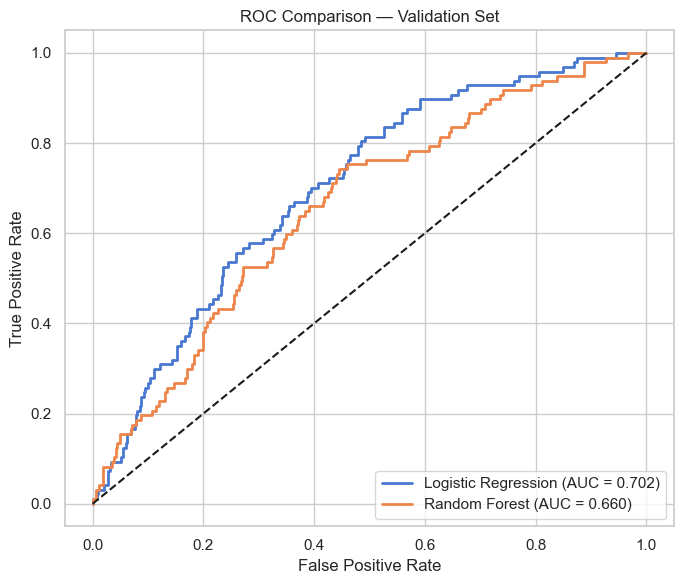

In [ ]:
plt.figure(figsize=(8, 6))
for name, y_prob in [('Logistic Regression', lr_prob_val), ('Random Forest', rf_prob_val), ('SVM', svm_prob_val), ('XGBoost', xgb_prob_val)]:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison — Validation Set (All Models)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()